In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display 

df=pd.read_csv('clustering_data.csv')
display(df.head())
display(df.info())

C:\Users\ANEESHSHASTRI\AppData\Local\Temp\ipykernel_12512\3283548714.py:7: DtypeWarning: Columns (0: Latitude) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('clustering_data.csv')


,CircleName,RegionName,DivisionName,OfficeName,Pincode,OfficeType,Delivery,District,StateName,Latitude,Longitude
0,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Peddakotla B.O,515631,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.5689,77.85624
1,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Pinnadhari B.O,515631,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.5281,77.857014
2,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Yerraguntapalle B.O,515631,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.561111,77.85715
3,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Obulareddipalli B.O,515581,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.2488,78.2588
4,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Odulapalli B.O,515581,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.24555,78.2477


<class 'pandas.DataFrame'>
RangeIndex: 157126 entries, 0 to 157125
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   CircleName    157126 non-null  str   
 1   RegionName    157073 non-null  str   
 2   DivisionName  157124 non-null  str   
 3   OfficeName    157126 non-null  str   
 4   Pincode       157126 non-null  int64 
 5   OfficeType    157126 non-null  str   
 6   Delivery      157126 non-null  str   
 7   District      157126 non-null  str   
 8   StateName     157126 non-null  str   
 9   Latitude      148288 non-null  object
 10  Longitude     148283 non-null  str   
dtypes: int64(1), object(1), str(9)
memory usage: 13.2+ MB


None

In [26]:
Pincodes=df[df["CircleName"]=="Karnataka Circle"]["Pincode"].unique()

In [27]:
data=df[df["Pincode"].isin(Pincodes)]
display(data.head())
X=data[["Latitude","Longitude"]].values
display(X)

,CircleName,RegionName,DivisionName,OfficeName,Pincode,OfficeType,Delivery,District,StateName,Latitude,Longitude
429,Karnataka Circle,North Karnataka Region,Bidar Division,MANHALLI S.O,585447,PO,Delivery,BIDAR,KARNATAKA,17.8155,76.7971
430,Karnataka Circle,North Karnataka Region,Bidar Division,Aliabad B.O,585404,BO,Delivery,BIDAR,KARNATAKA,17.6258,78.5955
1202,Karnataka Circle,South Karnataka Region,Mangaluru Division,Bajal S.O,575009,PO,Delivery,DAKSHINA KANNADA,KARNATAKA,12.853372,74.878526
9790,Karnataka Circle,South Karnataka Region,Hassan Division,Aggunda B.O,573103,BO,Delivery,HASSAN,KARNATAKA,13.32,76.27
9791,Karnataka Circle,South Karnataka Region,Hassan Division,Amaragiri Tirupathi B.O,573103,BO,Delivery,HASSAN,KARNATAKA,13.33,76.27


array([['17.8155', '76.7971'],
       ['17.6258', '78.5955'],
       ['12.853372', '74.878526'],
       ...,
       [15.3619099, '75.1514951'],
       [15.3407672, '75.143347'],
       [15.5572968, '75.3533931']], shape=(9671, 2), dtype=object)

In [28]:
data.isnull().sum(),len(data)

(CircleName         0
 RegionName         0
 DivisionName       0
 OfficeName         0
 Pincode            0
 OfficeType         0
 Delivery           0
 District           0
 StateName          0
 Latitude        1275
 Longitude       1275
 dtype: int64,
 9671)

In [29]:
data_clean=data.dropna()
X=data_clean[["Longitude"]]
Y=data_clean[["Latitude"]]
display(X)
display(Y)

,Longitude
429,76.7971
430,78.5955
1202,74.878526
9790,76.27
9791,76.27
...,...
156499,75.1457373
156500,75.1228692
156501,75.1514951
156502,75.143347


,Latitude
429,17.8155
430,17.6258
1202,12.853372
9790,13.32
9791,13.33
...,...
156499,15.369069
156500,15.368268
156501,15.36191
156502,15.340767


In [30]:
display(X[X["Longitude"].str.contains(r'-|\+', na=False)])
display(Y[Y["Latitude"].str.contains(r'-|\+', na=False)])
""" Drop the rows with invalid Latitude and Longitude values """
X = X[~X["Longitude"].str.contains(r'-|\+', na=False) & ~Y["Latitude"].str.contains(r'-|\+', na=False)]
Y = Y[~Y["Latitude"].str.contains(r'-|\+', na=False) & ~X["Longitude"].str.contains(r'-|\+', na=False) ]
# The - at the end might mean that the value is negative, but it is safer to drop it as it is not a valid number.
X=X.astype(float)
Y=Y.astype(float)

X=X[(X['Longitude']<180) & (X['Longitude']>-180)]
Y=Y[(Y['Latitude']<90) & (Y['Latitude']>-90)]

,Longitude
19962,73.9883650-
20200,84.0283920-
20311,8.8119230-
20704,110.9323800-
21127,80.1914480-
21136,155.8850500-
53709,119.5246600-
151907,74.2652010-


,Latitude
20927,31.4398200-


In [31]:
x=np.array(X.values.T[0],dtype=np.float64)
y=np.array(Y.values.T[0],dtype=np.float64)

x,y

(array([76.7971   , 78.5955   , 74.878526 , ..., 75.1514951, 75.143347 ,
        75.3533931], shape=(8386,)),
 array([17.8155   , 17.6258   , 12.853372 , ..., 15.3619099, 15.3407672,
        15.5572968], shape=(8386,)))

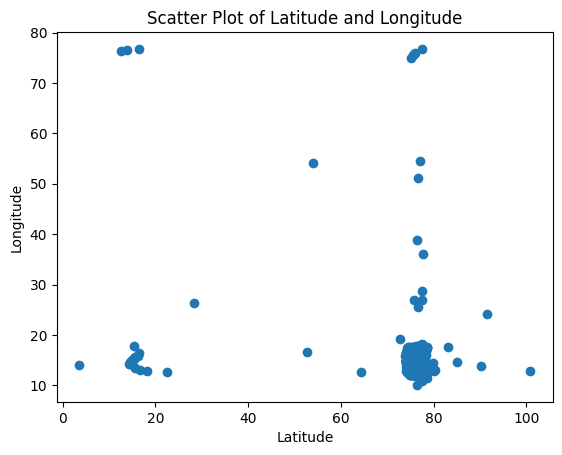

In [32]:

plt.scatter(x,y)
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("Scatter Plot of Latitude and Longitude")
plt.show()

In [33]:
#x=(x-x.mean())/x.std()
#y=(y-y.mean())/y.std()
# While normally, I would Normalise the data, it is important to note what I'm normalising.
# I genuinely don't know anything about this data, but I'm assuming it is the latitude and longitude from places where the letters are sent/recieved
# If so, then I'd likely want to cluster places that are close to each other, normalisation might mess with that.

In [34]:
# KMeans Clustering
class KMeans:
    def __init__(self, n_clusters=3, max_iters=100):
        self.n_clusters = n_clusters
        self.max_iters = max_iters

    def fit(self, X):
        # Randomly initialize centroids by selecting random samples from the data
        np.random.seed(42)  # For reproducibility
        """Random intialisation is not the best way, so I'll be using Kmeans++ intitialisation.
        random_indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)"""
        random_indices = np.random.choice(X.shape[0], 1, replace=False)
        for i in range(1, self.n_clusters):
            distances = np.linalg.norm(X[:, np.newaxis] - X[random_indices], axis=2)
            closest_distances = np.min(distances, axis=1)
            probabilities = closest_distances / np.sum(closest_distances)
            next_index = np.random.choice(X.shape[0], 1, p=probabilities)
            random_indices = np.append(random_indices, next_index)
        self.centroids = X[random_indices]

        for i in range(self.max_iters):
            # Assign clusters based on closest centroid
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2, ord=2)
            self.labels = np.argmin(distances, axis=1)

            # Update centroids
            new_centroids = np.array([X[self.labels == j].mean(axis=0) for j in range(self.n_clusters)])
            
            # Check for convergence (if centroids do not change)
            if np.all(self.centroids == new_centroids):
                print("Convergence reached.")
                break
            
            self.centroids = new_centroids
        return self.centroids
    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

Convergence reached.


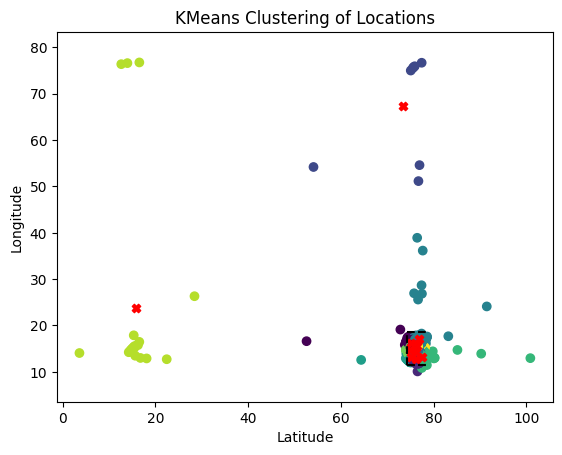

In [42]:
LL=np.stack((x,y), axis=1)

kmeans = KMeans(n_clusters=10,max_iters=1000)
centroids=kmeans.fit(LL)
labels = kmeans.predict(LL)
plt.scatter(x, y, c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X') 
plt.axis('equal')
 # Plot centroids
# 11°30' N and 18°30' N latitude and 74°15' E to 78°30' E longitude is the rough area of Karnataka, plot this as a rectangle for reference
plt.plot([74.25, 78.5],  [11.5, 11.5],color='black', linestyle='--')  # Top edge
plt.plot(  [74.25, 78.5],[18.5, 18.5], color='black', linestyle='--')  # Bottom edge
plt.plot(  [74.25, 74.25],[11.5, 18.5], color='black', linestyle='--')  # Left edge
plt.plot( [74.25, 78.5], [11.5, 11.5], color='black', linestyle='--')  # Right edge   

plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("KMeans Clustering of Locations")
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


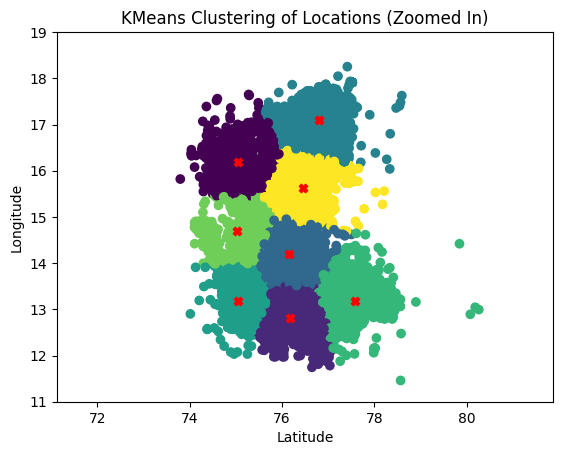

In [41]:
"""Let's concern ourselves with only the intrastate clustering"""
plt.figure()
plt.scatter(x, y, c=labels, cmap='viridis')
plt.axis('equal')  # Set equal aspect ratio
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X')  
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("KMeans Clustering of Locations (Zoomed In)")
plt.xlim(74, 79)
plt.ylim(11, 19)
plt.show()